# Simulación
Se deja a continuacion una simulacion para evaluar el comportamiento contra la mejor funcion encontrada segun parametros arbitrarios

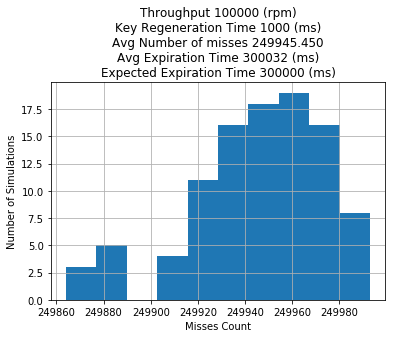

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import random
import math

def get_expiration_probability_exp11(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return (math.exp(invzone*11.0)-1)/(math.exp(11)-1.0)

def request_is_miss(timestamp,age,ttl,regeneration_time):
    time=timestamp+age
    delta=regeneration_time
    beta=1
    expiry=ttl
    
    if time+(delta*beta*math.log(random.random())) >= expiry:
        return True
    return False

def simulate_count_misses(throughput_rpm,regeneration_time,ttl):
    age=np.arange(0., ttl*1.5, 60000/throughput_rpm)
    misses=0
    timestamp=0
    for k in age:
        if request_is_miss(timestamp,k,ttl,regeneration_time):
            misses+=1
            if timestamp==0:
                timestamp=k+regeneration_time
                
    return misses,(timestamp-regeneration_time)
        
def print_misses_count_simulation_histogram(rpm,regeneration_time,ttl,steps):
    count_misses=[]
    key_ttls=[]
    for i in range(0,steps):
        mcnt,kttl=simulate_count_misses(rpm,regeneration_time,ttl)
        count_misses.append(mcnt)
        key_ttls.append(kttl)

    avg=np.average(count_misses)    
    avgttl=np.average(key_ttls)    
    plt.hist(count_misses)
    plt.xlabel('Misses Count')
    plt.ylabel('Number of Simulations')
    plt.title('Throughput %d (rpm)\n'
              'Key Regeneration Time %d (ms)\n'
              'Avg Number of misses %.3f\n'
              'Avg Expiration Time %d (ms)\n'
              'Expected Expiration Time %d (ms)' %(rpm,regeneration_time,avg,avgttl,ttl))
    plt.grid(True)
    plt.show()
    
    
# Correr una simulacion rapida o lenta(mas precisa)    
do_fast_simulation=False

# Throughput en request por minuto
throughput_rpm=100000 # 100 krpm

# Tiempo en milisegundos que demora regenerar una key que dio miss
key_regeneration_time_mills=1000  # 1 segundo

# Tiempo de vida maximo de una key en el cache en milisegundos
cache_expiration_time_mills=5*60*1000 # 5 minutos

print_misses_count_simulation_histogram(throughput_rpm,key_regeneration_time_mills,cache_expiration_time_mills,10 if do_fast_simulation else 100)

In [29]:
math.log(0.00001)

-11.512925464970229